In [1]:
# =========================================================
# LOAD TEMPERATURE SHEET
# =========================================================

import pandas as pd

file_path = "Data_file.xlsx"
sheet_name = "Temperature"

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Temperature Sheet Loaded Successfully!")
print("Shape of Dataset:", df.shape)

print("\nColumns in Temperature Sheet:")
print(df.columns.tolist())

df.head()

Temperature Sheet Loaded Successfully!
Shape of Dataset: (61, 32)

Columns in Temperature Sheet:
['Jsc', 'v(V)', 'T=300', 'T=330', 'T=360', 'T=390', 'T=420', 'T=450', 'Unnamed: 8', 'Unnamed: 9', 'Temperature', 'Jsc(mA/cm^2', 'Unnamed: 12', 'Unnamed: 13', 'Q.E.(%)', 'lambda(nm)', 'T=300.1', 'T=330.1', 'T=360.1', 'T=390.1', 'T=420.1', 'T=450.1', 'Unnamed: 22', 'Unnamed: 23', 'R(A/W)', 'lambda(nm).1', 'T=300.2', 'T=330.2', 'T=360.2', 'T=390.2', 'T=420.2', 'T=450.2']


,Jsc,v(V),T=300,T=330,T=360,T=390,T=420,T=450,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,R(A/W),lambda(nm).1,T=300.2,T=330.2,T=360.2,T=390.2,T=420.2,T=450.2
0,NaN,0.00,23.596469,24.379454,24.683406,24.823034,24.920193,24.999822,NaN,NaN,...,NaN,NaN,NaN,300,0.203713,0.204224,0.204666,0.205052,0.205391,0.205691
1,NaN,0.05,23.596327,24.379335,24.683307,24.822938,24.920098,24.999729,NaN,NaN,...,NaN,NaN,NaN,310,0.212987,0.213496,0.213937,0.214322,0.214660,0.214958
2,NaN,0.10,23.596181,24.379211,24.683202,24.822832,24.919990,24.999619,NaN,NaN,...,NaN,NaN,NaN,320,0.222504,0.223012,0.223450,0.223831,0.224166,0.224461
3,NaN,0.15,23.596031,24.379081,24.683089,24.822713,24.919863,24.999482,NaN,NaN,...,NaN,NaN,NaN,330,0.232310,0.232812,0.233245,0.233621,0.233951,0.234242
4,NaN,0.20,23.595875,24.378945,24.682965,24.822578,24.919710,24.999299,NaN,NaN,...,NaN,NaN,NaN,340,0.242466,0.242960,0.243385,0.243754,0.244077,0.244362


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [5]:
# =========================================================
# EXTRACT J-V DATA (TEMPERATURE)
# =========================================================

# Select voltage + J-V columns only
jv_cols = ['v(V)'] + [
    col for col in df.columns
    if str(col).startswith('T=') and '.1' not in str(col) and '.2' not in str(col)
]

# Create J-V dataframe
jv_df = df[jv_cols]

# Convert wide to long format
jv_long = jv_df.melt(
    id_vars='v(V)',
    var_name='Temperature',
    value_name='Current'
)

# Extract numeric temperature
jv_long['Temperature'] = jv_long['Temperature'].str.extract(r'T=(\d+)').astype(float)

# Remove NaN values
jv_long.dropna(inplace=True)

# Rename columns
jv_long.rename(columns={'v(V)': 'Voltage'}, inplace=True)

# Reset index
jv_long.reset_index(drop=True, inplace=True)

print("J-V Temperature Data Ready!")
print("Shape:", jv_long.shape)

jv_long.head()

J-V Temperature Data Ready!
Shape: (138, 3)


,Voltage,Temperature,Current
0,0.00,300.0,23.596469
1,0.05,300.0,23.596327
2,0.10,300.0,23.596181
3,0.15,300.0,23.596031
4,0.20,300.0,23.595875


In [6]:
# =========================================================
# EXTRACT QE DATA (TEMPERATURE)
# =========================================================

# Select wavelength + QE columns only
qe_cols = ['lambda(nm)'] + [
    col for col in df.columns
    if str(col).startswith('T=') and '.1' in str(col)
]

# Create QE dataframe
qe_df = df[qe_cols]

# Convert wide to long format
qe_long = qe_df.melt(
    id_vars='lambda(nm)',
    var_name='Temperature',
    value_name='QE'
)

# Extract numeric temperature
qe_long['Temperature'] = qe_long['Temperature'].str.extract(r'T=(\d+)').astype(float)

# Remove NaN values
qe_long.dropna(inplace=True)

# Rename columns
qe_long.rename(columns={'lambda(nm)': 'Wavelength'}, inplace=True)

# Reset index
qe_long.reset_index(drop=True, inplace=True)

print("QE Temperature Data Ready!")
print("Shape:", qe_long.shape)

qe_long.head()

QE Temperature Data Ready!
Shape: (366, 3)


,Wavelength,Temperature,QE
0,300,300.0,84.20150
1,310,300.0,85.19468
2,320,300.0,86.22042
3,330,300.0,87.29208
4,340,300.0,88.42871


In [7]:
# =========================================================
# EXTRACT RESPONSIVITY DATA (TEMPERATURE)
# =========================================================

# Select wavelength + Responsivity columns only
r_cols = ['lambda(nm).1'] + [
    col for col in df.columns
    if str(col).startswith('T=') and '.2' in str(col)
]

# Create Responsivity dataframe
r_df = df[r_cols]

# Convert wide to long format
r_long = r_df.melt(
    id_vars='lambda(nm).1',
    var_name='Temperature',
    value_name='Responsivity'
)

# Extract numeric temperature
r_long['Temperature'] = r_long['Temperature'].str.extract(r'T=(\d+)').astype(float)

# Remove NaN values
r_long.dropna(inplace=True)

# Rename columns
r_long.rename(columns={'lambda(nm).1': 'Wavelength'}, inplace=True)

# Reset index
r_long.reset_index(drop=True, inplace=True)

print("Responsivity Temperature Data Ready!")
print("Shape:", r_long.shape)

r_long.head()

Responsivity Temperature Data Ready!
Shape: (366, 3)


,Wavelength,Temperature,Responsivity
0,300,300.0,0.203713
1,310,300.0,0.212987
2,320,300.0,0.222504
3,330,300.0,0.232310
4,340,300.0,0.242466


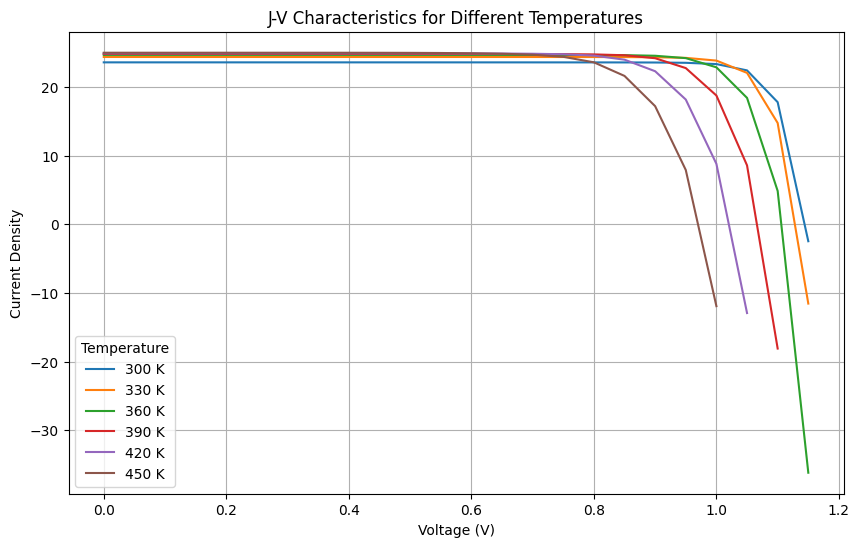

In [10]:
# =========================================================
# PLOT J-V CURVES (TEMPERATURE)
# =========================================================

plt.figure(figsize=(10,6))

for temperature in sorted(jv_long['Temperature'].unique()):
    subset = jv_long[jv_long['Temperature'] == temperature]

    plt.plot(
        subset['Voltage'],
        subset['Current'],
        label=f'{int(temperature)} K'
    )

plt.title("J-V Characteristics for Different Temperatures")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density")

plt.legend(title="Temperature")
plt.grid(True)
plt.show()

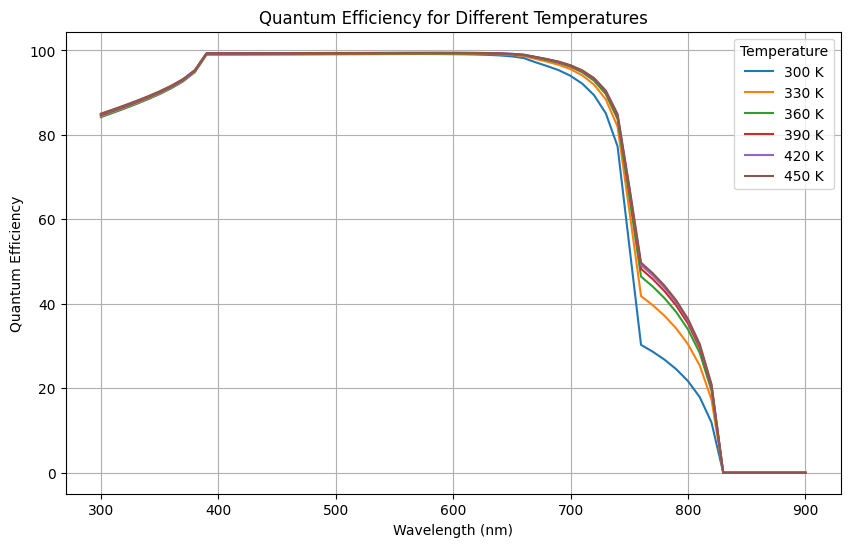

In [13]:
# =========================================================
# PLOT QE CURVES (TEMPERATURE)
# =========================================================

plt.figure(figsize=(10,6))

for temperature in sorted(qe_long['Temperature'].unique()):
    subset = qe_long[qe_long['Temperature'] == temperature]

    plt.plot(
        subset['Wavelength'],
        subset['QE'],
        label=f'{int(temperature)} K'
    )

plt.title("Quantum Efficiency for Different Temperatures")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency")

plt.legend(title="Temperature")
plt.grid(True)
plt.show()

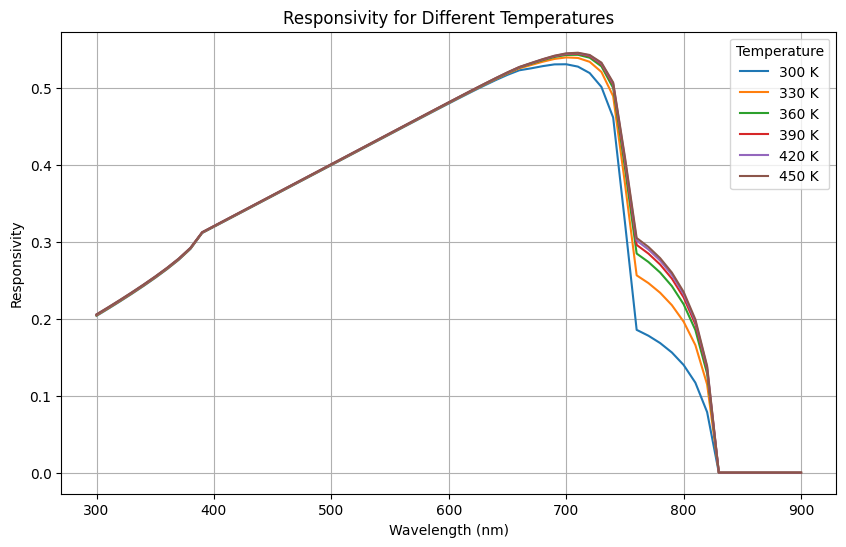

In [14]:
# =========================================================
# PLOT RESPONSIVITY CURVES (TEMPERATURE)
# =========================================================

plt.figure(figsize=(10,6))

for temperature in sorted(r_long['Temperature'].unique()):
    subset = r_long[r_long['Temperature'] == temperature]

    plt.plot(
        subset['Wavelength'],
        subset['Responsivity'],
        label=f'{int(temperature)} K'
    )

plt.title("Responsivity for Different Temperatures")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity")

plt.legend(title="Temperature")
plt.grid(True)
plt.show()

J-V Temperature Model Performance
R² Score: 0.6144030622763612
MAE: 0.5933834177571404


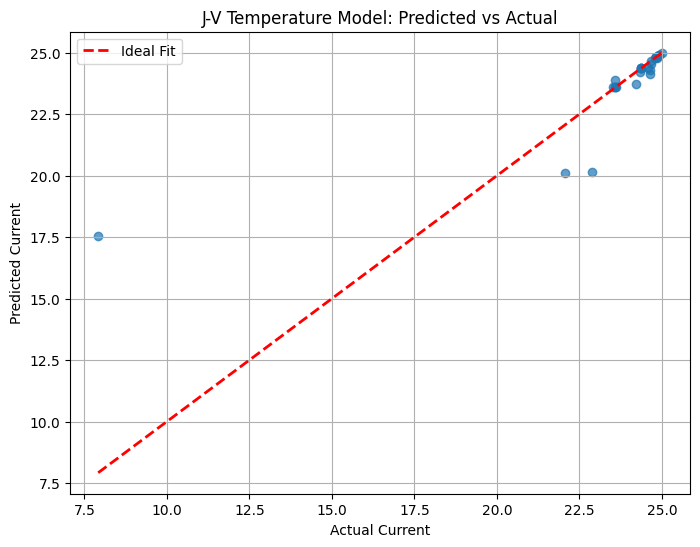

In [11]:
# =========================================================
# J-V MACHINE LEARNING MODEL (TEMPERATURE)
# =========================================================

# Features and target
X_jv = jv_long[['Voltage', 'Temperature']]
y_jv = jv_long['Current']

# Train-test split
X_train_jv, X_test_jv, y_train_jv, y_test_jv = train_test_split(
    X_jv, y_jv,
    test_size=0.2,
    random_state=42
)

# Model
jv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
jv_model.fit(X_train_jv, y_train_jv)

# Predict
y_pred_jv = jv_model.predict(X_test_jv)

# Metrics
print("J-V Temperature Model Performance")
print("R² Score:", r2_score(y_test_jv, y_pred_jv))
print("MAE:", mean_absolute_error(y_test_jv, y_pred_jv))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_jv, y_pred_jv, alpha=0.7)

# Ideal reference line
min_val = min(y_test_jv.min(), y_pred_jv.min())
max_val = max(y_test_jv.max(), y_pred_jv.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")
plt.title("J-V Temperature Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

QE Temperature Model Performance
R² Score: 0.9988336231676112
MAE: 0.3668858101232645


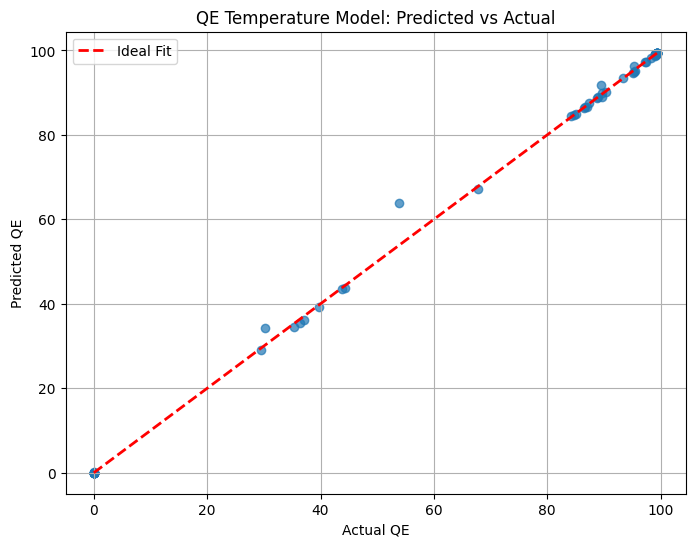

In [12]:
# =========================================================
# QE MACHINE LEARNING MODEL (TEMPERATURE)
# =========================================================

# Features and target
X_qe = qe_long[['Wavelength', 'Temperature']]
y_qe = qe_long['QE']

# Train-test split
X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(
    X_qe, y_qe,
    test_size=0.2,
    random_state=42
)

# Model
qe_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
qe_model.fit(X_train_qe, y_train_qe)

# Predict
y_pred_qe = qe_model.predict(X_test_qe)

# Metrics
print("QE Temperature Model Performance")
print("R² Score:", r2_score(y_test_qe, y_pred_qe))
print("MAE:", mean_absolute_error(y_test_qe, y_pred_qe))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_qe, y_pred_qe, alpha=0.7)

# Ideal reference line
min_val = min(y_test_qe.min(), y_pred_qe.min())
max_val = max(y_test_qe.max(), y_pred_qe.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")
plt.title("QE Temperature Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

Responsivity Temperature Model Performance
R² Score: 0.9979694892637369
MAE: 0.002325986903237329


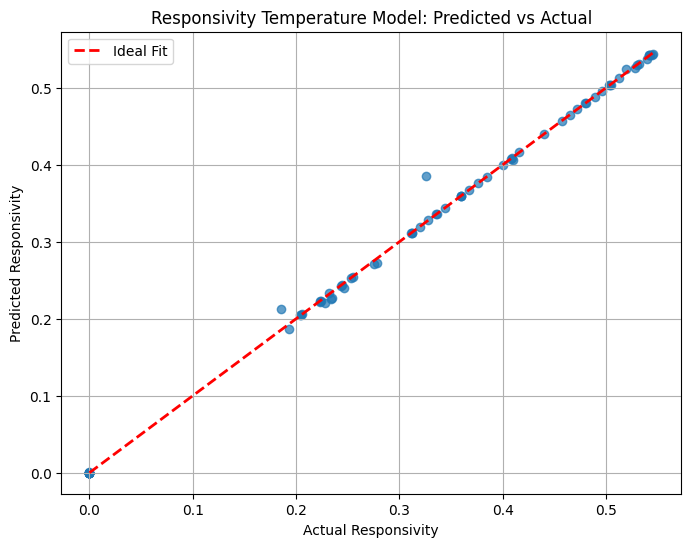

In [15]:
# =========================================================
# RESPONSIVITY MACHINE LEARNING MODEL (TEMPERATURE)
# =========================================================

# Features and target
X_r = r_long[['Wavelength', 'Temperature']]
y_r = r_long['Responsivity']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.2,
    random_state=42
)

# Model
r_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
r_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = r_model.predict(X_test_r)

# Metrics
print("Responsivity Temperature Model Performance")
print("R² Score:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.7)

# Ideal reference line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")
plt.title("Responsivity Temperature Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

In [16]:
# =========================================================
# PREDICT CURRENT (TEMPERATURE)
# =========================================================

def predict_current(voltage, temperature):

    prediction = jv_model.predict([[voltage, temperature]])[0]

    print(f"Predicted Current Density at {voltage} V and {temperature} K: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

voltage = float(input("Enter Voltage (V): "))
temperature = float(input("Enter Temperature (K): "))

predict_current(voltage, temperature)

In [17]:
# =========================================================
# PREDICT QE (TEMPERATURE)
# =========================================================

def predict_qe(wavelength, temperature):

    prediction = qe_model.predict([[wavelength, temperature]])[0]

    print(f"Predicted QE at {wavelength} nm and {temperature} K: {prediction}")

    return prediction

In [18]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
temperature = float(input("Enter Temperature (K): "))

predict_qe(wavelength, temperature)

Predicted QE at 500.0 nm and 400.0 K: 99.30554275000013


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(99.30554275000013)

In [ ]:
# =========================================================
# PREDICT RESPONSIVITY (TEMPERATURE)
# =========================================================

def predict_responsivity(wavelength, temperature):

    prediction = r_model.predict([[wavelength, temperature]])[0]

    print(f"Predicted Responsivity at {wavelength} nm and {temperature} K: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
temperature = float(input("Enter Temperature (K): "))

predict_responsivity(wavelength, temperature)

In [19]:
# =========================================================
# PREDICT FULL J-V CURVE (TEMPERATURE)
# =========================================================

def predict_jv_curve(temperature):

    voltage_range = np.linspace(
        jv_long['Voltage'].min(),
        jv_long['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Temperature': temperature
    })

    predicted_current = jv_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_current,
        label=f'Predicted Temperature = {temperature} K'
    )

    plt.title("Predicted J-V Curve")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

temperature = float(input("Enter Temperature (K): "))

predict_jv_curve(temperature)

In [ ]:
# =========================================================
# PREDICT FULL QE CURVE (TEMPERATURE)
# =========================================================

def predict_qe_curve(temperature):

    wavelength_range = np.linspace(
        qe_long['Wavelength'].min(),
        qe_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Temperature': temperature
    })

    predicted_qe = qe_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_qe,
        label=f'Predicted Temperature = {temperature} K'
    )

    plt.title("Predicted QE Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

temperature = float(input("Enter Temperature (K): "))

predict_qe_curve(temperature)

In [ ]:
# =========================================================
# PREDICT FULL RESPONSIVITY CURVE (TEMPERATURE)
# =========================================================

def predict_r_curve(temperature):

    wavelength_range = np.linspace(
        r_long['Wavelength'].min(),
        r_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Temperature': temperature
    })

    predicted_r = r_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_r,
        label=f'Predicted Temperature = {temperature} K'
    )

    plt.title("Predicted Responsivity Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

temperature = float(input("Enter Temperature (K): "))

predict_r_curve(temperature)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED J-V CURVE (TEMPERATURE)
# =========================================================

def compare_jv_actual_vs_predicted(temperature):

    # Actual SCAPS data
    actual_data = jv_long[jv_long['Temperature'] == temperature]

    if actual_data.empty:
        print("Temperature not found in dataset.")
        return

    # Predicted curve
    voltage_range = np.linspace(
        actual_data['Voltage'].min(),
        actual_data['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Temperature': temperature
    })

    predicted_current = jv_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Voltage'],
        actual_data['Current'],
        label="Actual SCAPS"
    )

    plt.plot(
        voltage_range,
        predicted_current,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted J-V Curve ({temperature} K)")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

temperature = float(input("Enter Existing Temperature (K): "))

compare_jv_actual_vs_predicted(temperature)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED QE CURVE (TEMPERATURE)
# =========================================================

def compare_qe_actual_vs_predicted(temperature):

    # Actual SCAPS data
    actual_data = qe_long[qe_long['Temperature'] == temperature]

    if actual_data.empty:
        print("Temperature not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Temperature': temperature
    })

    predicted_qe = qe_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['QE'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_qe,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted QE Curve ({temperature} K)")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

temperature = float(input("Enter Existing Temperature (K): "))

compare_qe_actual_vs_predicted(temperature)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED RESPONSIVITY CURVE (TEMPERATURE)
# =========================================================

def compare_r_actual_vs_predicted(temperature):

    # Actual SCAPS data
    actual_data = r_long[r_long['Temperature'] == temperature]

    if actual_data.empty:
        print("Temperature not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Temperature': temperature
    })

    predicted_r = r_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['Responsivity'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_r,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted Responsivity Curve ({temperature} K)")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

temperature = float(input("Enter Existing Temperature (K): "))

compare_r_actual_vs_predicted(temperature)

In [20]:
# =========================================================
# TEMPERATURE THEORY + SYSTEM WORKING
# =========================================================

print("""
============================================================
TEMPERATURE VARIATION THEORY IN PEROVSKITE SOLAR CELLS
============================================================

In this project, temperature is treated as an important external 
operating parameter that affects the photovoltaic behavior of the 
perovskite solar cell.

Unlike structural parameters such as ETL or PVK thickness, 
temperature does not change the physical dimensions of the device, 
but it significantly influences the internal electrical and optical 
processes occurring inside the solar cell.

------------------------------------------------------------
WHY TEMPERATURE IS IMPORTANT
------------------------------------------------------------

Temperature affects:
• Carrier mobility
• Recombination behavior
• Semiconductor bandgap
• Charge transport
• Current density
• Spectral response

As temperature changes:
• Carrier energy changes
• Charge transport may vary
• Recombination rates may shift
• Electrical output may change

Thus, studying temperature variation helps analyze how the device 
behaves under different thermal operating conditions.

------------------------------------------------------------
ROLE OF SCAPS DATASET
------------------------------------------------------------

The Excel dataset contains SCAPS-generated simulation data for 
multiple temperature values.

For each temperature condition, SCAPS provides:

1. J–V Data:
Voltage vs Current Density

2. QE Data:
Wavelength vs Quantum Efficiency

3. Responsivity Data:
Wavelength vs Responsivity

Each temperature therefore represents a distinct simulated device 
behavior under different thermal conditions.

------------------------------------------------------------
WHAT THIS ML SYSTEM DOES
------------------------------------------------------------

Instead of manually analyzing every temperature separately, 
Machine Learning is used to identify patterns across thermal data.

Three Random Forest models are trained:

J–V Model:
(Voltage + Temperature) → Current

QE Model:
(Wavelength + Temperature) → QE

Responsivity Model:
(Wavelength + Temperature) → Responsivity

This allows prediction of:
• Current at user-defined voltage and temperature
• QE at user-defined wavelength and temperature
• Responsivity at user-defined wavelength and temperature
• Full predicted curves for selected temperature

------------------------------------------------------------
MODEL VALIDATION
------------------------------------------------------------

To ensure prediction reliability:
• R² Score measures predictive accuracy
• MAE measures average error
• Predicted vs Actual plots verify consistency

These validation methods help confirm whether ML has properly 
captured SCAPS thermal trends.

------------------------------------------------------------
ACTUAL vs PREDICTED COMPARISON
------------------------------------------------------------

For known temperature values:
• Actual SCAPS curves are plotted
• Predicted ML curves are plotted

This comparison helps evaluate:
• Learning quality
• Predictive consistency
• Reliability of thermal trend modeling

------------------------------------------------------------
SYSTEM SIGNIFICANCE
------------------------------------------------------------

This framework combines:
SCAPS Simulation + Thermal Analysis + Machine Learning

Thus, it serves as:
• Temperature-response analysis tool
• Predictive modeling framework
• Visualization system

Rather than replacing SCAPS, this system extends thermal analysis 
by enabling:
• Faster prediction
• User-defined temperature exploration
• Efficient comparison

============================================================
FINAL SUMMARY
============================================================

Temperature is a critical operational parameter.
It affects solar-cell electrical and optical behavior.
SCAPS provides temperature-based simulation data.
Machine Learning learns temperature-response patterns.
The final system predicts and visualizes temperature effects.

In short:
This project creates a reusable temperature-based simulation 
and prediction framework for perovskite solar-cell analysis.
============================================================
""")


TEMPERATURE VARIATION THEORY IN PEROVSKITE SOLAR CELLS

In this project, temperature is treated as an important external 
operating parameter that affects the photovoltaic behavior of the 
perovskite solar cell.

Unlike structural parameters such as ETL or PVK thickness, 
temperature does not change the physical dimensions of the device, 
but it significantly influences the internal electrical and optical 
processes occurring inside the solar cell.

------------------------------------------------------------
WHY TEMPERATURE IS IMPORTANT
------------------------------------------------------------

Temperature affects:
• Carrier mobility
• Recombination behavior
• Semiconductor bandgap
• Charge transport
• Current density
• Spectral response

As temperature changes:
• Carrier energy changes
• Charge transport may vary
• Recombination rates may shift
• Electrical output may change

Thus, studying temperature variation helps analyze how the device 
behaves under different thermal operat